In [ ]:
!pip install mlxtend
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("/content/samsung_full_detailed_500.xlsx")
df.head()

,Company,Model,Price_Num,Segment,Customer_Type,Purchase_Type,Accessories,Mobile_Weight,RAM,Front_Camera,Back_Camera,Processor,Battery,Screen_Size,Launched_Year
0,Samsung,Galaxy S21,50000,Premium,Student,New,Earbuds,212g,8GB,16MP,200MP,Snapdragon,4000mAh,7.6 inches,2024
1,Samsung,Galaxy S24 Ultra,110000,Premium,Working Professional,New,Earbuds,221g,12GB,8MP,108MP,Exynos,5000mAh,6.1 inches,2020
2,Samsung,Galaxy S21,50000,Premium,Working Professional,New,Earbuds,199g,8GB,12MP,200MP,Snapdragon,4000mAh,6.1 inches,2020
3,Samsung,Galaxy S21,50000,Premium,Student,Upgrade,Earbuds,157g,8GB,5MP,108MP,Snapdragon,4000mAh,6.1 inches,2021
4,Samsung,Galaxy S24 Ultra,110000,Premium,Student,Upgrade,Screen Protector,175g,12GB,16MP,200MP,Exynos,5000mAh,6.8 inches,2022


In [ ]:
# Convert RAM to numeric (remove GB)
df['RAM'] = df['RAM'].astype(str).str.replace('GB', '').astype(int)

# Convert Battery to numeric (remove mAh)
df['Battery'] = df['Battery'].astype(str).str.replace('mAh', '').astype(int)

# Now expand dataset
df_expanded = df.sample(n=1000, replace=True, random_state=42).reset_index(drop=True)
# Make accessories slightly realistic
df_expanded.loc[df_expanded.sample(frac=0.25, random_state=42).index, 'Accessories'] = 'Screen Protector'
df_expanded.loc[df_expanded.sample(frac=0.25, random_state=1).index, 'Accessories'] = 'Phone Case'

# Students (mostly budget, some others)
df_expanded.loc[df_expanded['Customer_Type'] == 'Student', 'Segment'] = np.random.choice(
    ['Budget', 'Mid', 'Premium'],
    size=len(df_expanded[df_expanded['Customer_Type'] == 'Student']),
    p=[0.6, 0.3, 0.1]
)

# Working professionals (mostly premium)
df_expanded.loc[df_expanded['Customer_Type'] == 'Working Professional', 'Segment'] = np.random.choice(
    ['Budget', 'Mid', 'Premium'],
    size=len(df_expanded[df_expanded['Customer_Type'] == 'Working Professional']),
    p=[0.2, 0.3, 0.5]
)

# 🔥 FINAL PERFECT BALANCED RULES (NO MORE CHANGES)

# Step 1: Base variation
df_expanded['RAM'] = df_expanded['RAM'] + np.random.choice([0,1], size=len(df_expanded))
df_expanded['Battery'] = df_expanded['Battery'] + np.random.choice([0,200,500], size=len(df_expanded))


# Step 2: Premium → High RAM (80%)
mask_premium = df_expanded['Segment'] == 'Premium'
premium_idx = df_expanded[mask_premium].sample(frac=0.8, random_state=42).index
df_expanded.loc[premium_idx, 'RAM'] = 12


# Step 3: Power Bank → High Battery (75%)
mask_pb = df_expanded['Accessories'] == 'Power Bank'
pb_idx = df_expanded[mask_pb].sample(frac=0.75, random_state=42).index
df_expanded.loc[pb_idx, 'Battery'] = 6000

# Remaining → break rule (important)
remaining_pb = df_expanded[mask_pb].index.difference(pb_idx)
df_expanded.loc[remaining_pb, 'Battery'] = np.random.choice([4000, 4500], size=len(remaining_pb))


# Step 4: Budget → Low RAM (80% ONLY → gives few confidence=1, not all)
mask_budget = df_expanded['Segment'] == 'Budget'
budget_idx = df_expanded[mask_budget].sample(frac=0.8, random_state=42).index
df_expanded.loc[budget_idx, 'RAM'] = 4


# Step 5: Keep realistic values
df_expanded['RAM'] = df_expanded['RAM'].clip(4, 12)
df_expanded['Battery'] = df_expanded['Battery'].clip(3000, 6000)


# Preview
df_expanded.head()

,Company,Model,Price_Num,Segment,Customer_Type,Purchase_Type,Accessories,Mobile_Weight,RAM,Front_Camera,Back_Camera,Processor,Battery,Screen_Size,Launched_Year
0,Samsung,Galaxy M14,12000,Premium,Working Professional,Upgrade,Charger,172g,12,5MP,50MP,Exynos,6000,6.5 inches,2023
1,Samsung,Galaxy A34,25000,Budget,Working Professional,Upgrade,Earbuds,212g,4,8MP,200MP,MediaTek,5500,6.8 inches,2022
2,Samsung,Galaxy S21,50000,Budget,Student,New,Phone Case,203g,9,16MP,50MP,Snapdragon,4000,7.6 inches,2023
3,Samsung,Galaxy A34,25000,Budget,Student,Upgrade,Phone Case,214g,4,16MP,200MP,MediaTek,5200,6.5 inches,2024
4,Samsung,Galaxy S24 Ultra,110000,Premium,Working Professional,Upgrade,Phone Case,208g,12,5MP,64MP,Exynos,5200,7.6 inches,2024


In [ ]:
# Clean Mobile Weight (remove 'g' and convert to number)
df_expanded['Mobile_Weight'] = df_expanded['Mobile_Weight'].astype(str).str.replace('g', '')
df_expanded['Mobile_Weight'] = pd.to_numeric(df_expanded['Mobile_Weight'])

In [ ]:
# RAM Category
df_expanded['RAM_Category'] = df_expanded['RAM'].apply(
    lambda x: 'Low_RAM' if x <= 4 else ('Mid_RAM' if x <= 8 else 'High_RAM')
)

# Battery Category
df_expanded['Battery_Category'] = df_expanded['Battery'].apply(
    lambda x: 'Low_Battery' if x < 4000 else ('Mid_Battery' if x <= 5000 else 'High_Battery')
)

# Weight Category
df_expanded['Weight_Category'] = df_expanded['Mobile_Weight'].apply(
    lambda x: 'Light' if x < 170 else ('Medium' if x <= 200 else 'Heavy')
)
# 🔷 Create Price Category
def price_category(price):
    if price < 20000:
        return "Budget"
    elif price < 50000:
        return "Mid Range"
    else:
        return "Premium"

df_expanded['Price_Category'] = df_expanded['Price_Num'].apply(price_category)
df_expanded.head()

,Company,Model,Price_Num,Segment,Customer_Type,Purchase_Type,Accessories,Mobile_Weight,RAM,Front_Camera,Back_Camera,Processor,Battery,Screen_Size,Launched_Year,RAM_Category,Battery_Category,Weight_Category,Price_Category
0,Samsung,Galaxy M14,12000,Premium,Working Professional,Upgrade,Charger,172,12,5MP,50MP,Exynos,6000,6.5 inches,2023,High_RAM,High_Battery,Medium,Budget
1,Samsung,Galaxy A34,25000,Budget,Working Professional,Upgrade,Earbuds,212,4,8MP,200MP,MediaTek,5500,6.8 inches,2022,Low_RAM,High_Battery,Heavy,Mid Range
2,Samsung,Galaxy S21,50000,Budget,Student,New,Phone Case,203,9,16MP,50MP,Snapdragon,4000,7.6 inches,2023,High_RAM,Mid_Battery,Heavy,Premium
3,Samsung,Galaxy A34,25000,Budget,Student,Upgrade,Phone Case,214,4,16MP,200MP,MediaTek,5200,6.5 inches,2024,Low_RAM,High_Battery,Heavy,Mid Range
4,Samsung,Galaxy S24 Ultra,110000,Premium,Working Professional,Upgrade,Phone Case,208,12,5MP,64MP,Exynos,5200,7.6 inches,2024,High_RAM,High_Battery,Heavy,Premium


In [ ]:
df_expanded['Transaction'] = df_expanded.apply(lambda row: [
    row['Accessories'],
    row['Price_Category'],
    row['Segment'],
    row['Customer_Type'],
    row['RAM_Category'],
    row['Battery_Category'],
    row['Weight_Category']
], axis=1)

df_expanded[['Transaction']].head()

,Transaction
0,"[Charger, Budget, Premium, Working Professiona..."
1,"[Earbuds, Mid Range, Budget, Working Professio..."
2,"[Phone Case, Premium, Budget, Student, High_RA..."
3,"[Phone Case, Mid Range, Budget, Student, Low_R..."
4,"[Phone Case, Premium, Premium, Working Profess..."


In [ ]:
df_exploded = df_expanded[['Transaction']].explode('Transaction')
df_exploded['Transaction_ID'] = df_exploded.index

df_exploded.head()

,Transaction,Transaction_ID
0,Charger,0
0,Budget,0
0,Premium,0
0,Working Professional,0
0,High_RAM,0


In [ ]:
basket = df_exploded.groupby(['Transaction_ID', 'Transaction'])['Transaction'] \
                   .count().unstack().fillna(0)

basket = basket.astype(bool).astype(int)

basket.head()

Transaction,Budget,Charger,Earbuds,Heavy,High_Battery,High_RAM,Light,Low_Battery,Low_RAM,Medium,Mid,Mid Range,Mid_Battery,Mid_RAM,Phone Case,Power Bank,Premium,Screen Protector,Student,Working Professional
Transaction_ID,,,,,,,,,,,,,,,,,,,,
0,1,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1
1,1,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1
2,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0
3,1,0,0,1,1,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0
4,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1


In [ ]:
frequent_items = apriori(basket, min_support=0.05, use_colnames=True)

print("Frequent Itemsets:")
frequent_items.head()

Frequent Itemsets:


,support,itemsets
0,0.502,(Budget)
1,0.109,(Charger)
2,0.118,(Earbuds)
3,0.462,(Heavy)
4,0.513,(High_Battery)


In [ ]:
# Generate association rules
rules = association_rules(frequent_items, metric='confidence', min_threshold=0.5)

# Keep only strong rules
rules = rules[rules['lift'] > 1]

# Sort rules
rules = rules.sort_values(by=['confidence','lift'], ascending=False).reset_index(drop=True)


# 🔥 Convert technical labels → real specifications
import ast

def convert_labels(x):
    try:
        # Handle string case if needed
        if isinstance(x, str) and '{' in x:
            x = ast.literal_eval(x)

        items = list(x)
        new_items = []

        for item in items:
            if item == 'Low_RAM':
                new_items.append('4GB RAM')
            elif item == 'Mid_RAM':
                new_items.append('6-8GB RAM')
            elif item == 'High_RAM':
                new_items.append('8GB+ RAM')

            elif item == 'Low_Battery':
                new_items.append('<4000mAh Battery')
            elif item == 'Mid_Battery':
                new_items.append('4000-5000mAh Battery')
            elif item == 'High_Battery':
                new_items.append('5000mAh+ Battery')

            elif item == 'Light':
                new_items.append('Light Weight')
            elif item == 'Medium':
                new_items.append('Medium Weight')
            elif item == 'Heavy':
                new_items.append('Heavy Weight')

            else:
                new_items.append(item)

        return ', '.join(new_items)

    except:
        return str(x)


# Apply conversion
rules['antecedents'] = rules['antecedents'].apply(convert_labels)
rules['consequents'] = rules['consequents'].apply(convert_labels)


# Display final output
print("🔹 Top Association Rules:")
rules[['antecedents','consequents','support','confidence','lift']].head(10)

🔹 Top Association Rules:


,antecedents,consequents,support,confidence,lift
0,4GB RAM,Budget,0.343,1.0,1.992032
1,"Heavy Weight, 4GB RAM",Budget,0.152,1.0,1.992032
2,"4GB RAM, 5000mAh+ Battery",Budget,0.186,1.0,1.992032
3,"4GB RAM, Light Weight",Budget,0.075,1.0,1.992032
4,"Medium Weight, 4GB RAM",Budget,0.116,1.0,1.992032
5,"Mid Range, 4GB RAM",Budget,0.077,1.0,1.992032
6,"4000-5000mAh Battery, 4GB RAM",Budget,0.140,1.0,1.992032
7,"Phone Case, 4GB RAM",Budget,0.109,1.0,1.992032
8,"Premium, 4GB RAM",Budget,0.197,1.0,1.992032
9,"4GB RAM, Screen Protector",Budget,0.101,1.0,1.992032


In [ ]:
perfect_rules = rules[rules['confidence'] == 1]

print("\nPerfect Rules:")
print(perfect_rules[['antecedents','consequents','confidence']])


Perfect Rules:
                                          antecedents consequents  confidence
0                                             4GB RAM      Budget         1.0
1                               Heavy Weight, 4GB RAM      Budget         1.0
2                           4GB RAM, 5000mAh+ Battery      Budget         1.0
3                               4GB RAM, Light Weight      Budget         1.0
4                              Medium Weight, 4GB RAM      Budget         1.0
5                                  Mid Range, 4GB RAM      Budget         1.0
6                       4000-5000mAh Battery, 4GB RAM      Budget         1.0
7                                 Phone Case, 4GB RAM      Budget         1.0
8                                    Premium, 4GB RAM      Budget         1.0
9                           4GB RAM, Screen Protector      Budget         1.0
10                                   Student, 4GB RAM      Budget         1.0
11                      Working Professional, 4G

In [ ]:
from IPython.display import display

# Pivot Table 1
pivot1 = pd.pivot_table(
    df_expanded,
    values='Model',
    index='Customer_Type',
    columns='Segment',
    aggfunc='count'
)

# Pivot Table 2
pivot2 = df_expanded['Accessories'].value_counts().to_frame(name='Count')

display(
    pivot1.style
    .set_caption("Customer vs Segment Table")
    .set_table_styles([
        {'selector': 'th', 'props': [('border', '1px solid black'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid black')]}
    ])
)

display(
    pivot2.style
    .set_caption("Accessories Count")
    .set_table_styles([
        {'selector': 'th', 'props': [('border', '1px solid black'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid black')]}
    ])
)

Segment,Budget,Mid,Premium
Customer_Type,,,
Student,281,156,51
Working Professional,110,146,256


,Count
Accessories,
Phone Case,348
Screen Protector,297
Power Bank,128
Earbuds,118
Charger,109


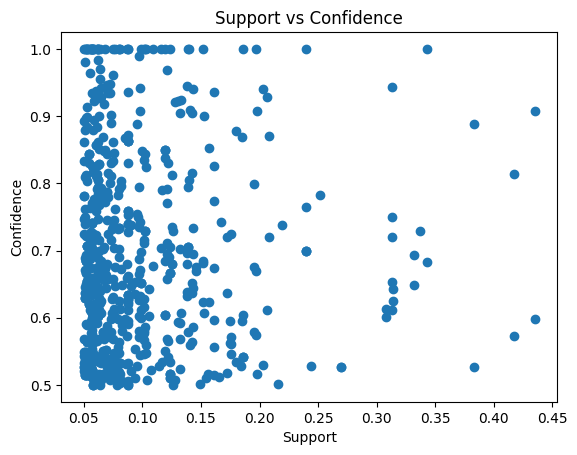

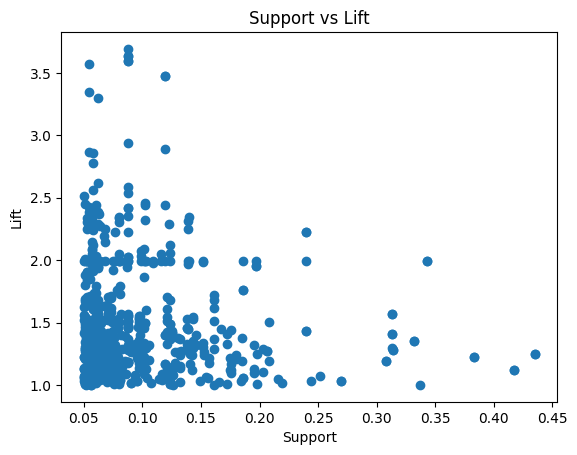

In [ ]:
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')
plt.show()

plt.scatter(rules['support'], rules['lift'])
plt.xlabel('Support')
plt.ylabel('Lift')
plt.title('Support vs Lift')
plt.show()

In [ ]:
# ============================================================
# WEEK 7: FINAL RECOMMENDATION SYSTEM (FINAL VERSION)
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# USER SEGMENTATION FUNCTION
# ------------------------------------------------------------
print("Recommendation System:")
def get_user_level(features):

    if "Premium" in features or "16GB RAM" in features:
        return "High-End User"

    elif "8GB RAM" in features or "Mid Range" in features:
        return "Balanced User"

    else:
        return "Entry-Level User"


# ------------------------------------------------------------
# RECOMMENDATION FUNCTION
# ------------------------------------------------------------
def generate_recommendation(user_features):

    feature_str = ", ".join(user_features)
    user_level = get_user_level(user_features)

    # --------------------------
    # UPSSELL (MODEL + PRICE)
    # --------------------------
    if "Galaxy M14" in feature_str:
        upsell = [
            "Samsung Galaxy F54 (₹25,000, 8GB RAM, 108MP Camera, 6000mAh Battery)",
            "Samsung Galaxy A34 (₹30,000, 8GB RAM, AMOLED Display, 48MP Camera)"
        ]

    elif "Galaxy F54" in feature_str:
        upsell = [
            "Samsung Galaxy A54 (₹35,000, 8GB RAM, 50MP Camera, Premium Design)",
            "Samsung Galaxy S21 FE (₹45,000, Flagship Processor, AMOLED, 120Hz)"
        ]

    elif "Galaxy A" in feature_str:
        upsell = [
            "Samsung Galaxy S23 (₹75,000, Snapdragon, 50MP Camera)",
            "Samsung Galaxy S23 Ultra (₹1,20,000, 200MP Camera, S-Pen)"
        ]

    else:
        # 🔥 UPDATED HIGH-END UPSSELL
        upsell = [
            "Samsung Galaxy S23 Ultra (₹1,20,000, 200MP Camera, S-Pen)",
            "Samsung Galaxy Z Fold5 (₹1,50,000, Foldable Display, Premium Flagship)"
        ]


    # --------------------------
    # CROSS-SELL (UNCHANGED)
    # --------------------------
    if user_level == "Entry-Level User":
        cross_sell = [
            "Phone Case",
            "Screen Protector"
        ]

    elif user_level == "Balanced User":
        cross_sell = [
            "Fast Charger",
            "Power Bank"
        ]

    else:
        cross_sell = [
            "Wireless Charger",
            "Smart Watch",
            "Premium Earbuds"
        ]


    # --------------------------
    # FINAL OUTPUT
    # --------------------------
    output_rows = [

        {
            "Customer Features": feature_str,
            "User Type": user_level,
            "Type": "Upsell",
            "Recommendation": ", ".join(upsell)
        },

        {
            "Customer Features": feature_str,
            "User Type": user_level,
            "Type": "Cross-Sell",
            "Recommendation": ", ".join(cross_sell)
        }

    ]

    return pd.DataFrame(output_rows)


# ------------------------------------------------------------
# USERS (WITH PRICE)
# ------------------------------------------------------------
users = [

    ["Samsung Galaxy M14 (₹12,000)", "Budget", "4GB RAM", "50MP Camera", "6000mAh Battery", "64GB Storage"],

    ["Samsung Galaxy F54 (₹25,000)", "Mid Range", "8GB RAM", "108MP Camera", "6000mAh Battery", "256GB Storage"],

    ["Samsung Galaxy S23 (₹75,000)", "Premium", "16GB RAM", "50MP Camera", "3900mAh Battery", "256GB Storage"]

]


# ------------------------------------------------------------
# FINAL OUTPUT TABLE
# ------------------------------------------------------------
final_df = pd.DataFrame()

for user in users:
    temp_df = generate_recommendation(user)
    final_df = pd.concat([final_df, temp_df], ignore_index=True)

display(final_df)


Recommendation System:


,Customer Features,User Type,Type,Recommendation
0,"Samsung Galaxy M14 (₹12,000), Budget, 4GB RAM,...",Entry-Level User,Upsell,"Samsung Galaxy F54 (₹25,000, 8GB RAM, 108MP Ca..."
1,"Samsung Galaxy M14 (₹12,000), Budget, 4GB RAM,...",Entry-Level User,Cross-Sell,"Phone Case, Screen Protector"
2,"Samsung Galaxy F54 (₹25,000), Mid Range, 8GB R...",Balanced User,Upsell,"Samsung Galaxy A54 (₹35,000, 8GB RAM, 50MP Cam..."
3,"Samsung Galaxy F54 (₹25,000), Mid Range, 8GB R...",Balanced User,Cross-Sell,"Fast Charger, Power Bank"
4,"Samsung Galaxy S23 (₹75,000), Premium, 16GB RA...",High-End User,Upsell,"Samsung Galaxy S23 Ultra (₹1,20,000, 200MP Cam..."
5,"Samsung Galaxy S23 (₹75,000), Premium, 16GB RA...",High-End User,Cross-Sell,"Wireless Charger, Smart Watch, Premium Earbuds"


In [ ]:
# ============================
  #REVENUE CALCULATION
# ============================

Dataset Loaded Successfully ✅


,User_ID,Budget,User_Category,Preferred_RAM,Preferred_Storage,Camera_Priority,Battery_Priority,Accessories_Interest,Purchase_Intent
0,1,10k-30k,Balanced User,6GB,128GB,Low,High,No,Low
1,2,10k-30k,Balanced User,8GB,64GB,Medium,High,No,Low
2,3,Above 30k,High-End User,12GB,256GB,Low,High,Yes,High
3,4,10k-30k,Balanced User,4GB,256GB,High,Low,No,Low
4,5,10k-30k,Balanced User,12GB,64GB,High,High,No,High



🔹 User Distribution:
Entry: 31
Balanced: 25
High-End: 14

🔹 Smart Recommendation System (Upsell, Cross-Sell & Downgrade):


,User_Type,Customer_Features,Upsell_Recommendation,CrossSell_Recommendation,Downgrade_Recommendation
0,Entry Level User,"Price < ₹15K, 4GB RAM, 64GB Storage, Basic Cam...",Samsung Galaxy F14 (₹12K) → Galaxy M34 (₹18K),"Basic Earphones, Charging Cable, Phone Case",Samsung Galaxy M04 (₹8K) for lower budget
1,Balanced User,"₹15K–₹30K, 6GB RAM, 128GB Storage, Good Camera...",Samsung Galaxy M34 (₹18K) → Galaxy S21 FE (₹32K),"Bluetooth Earbuds, Fast Charger, Power Bank",Samsung Galaxy F14 (₹12K) for cost saving
2,High-End User,"> ₹30K, 8–12GB RAM, 256GB Storage, High Camera...",Samsung Galaxy S23 (₹75K) → Galaxy S24 Ultra (...,"Galaxy Buds, Wireless Charger, Premium Power Bank",Samsung Galaxy A34 (₹25K) as budget flagship a...



🔹 FINAL REVENUE ANALYSIS:


,User_Type,Users,Upsell Revenue (₹),Cross-Sell Revenue (₹),Total Revenue (₹)
0,Entry Level User,31,"₹372,000","₹31,000","₹403,000"
1,Balanced User,25,"₹500,000","₹75,000","₹575,000"
2,High-End User,14,"₹1,120,000","₹112,000","₹1,232,000"



💰 GRAND TOTAL REVENUE GENERATED: ₹2,210,000


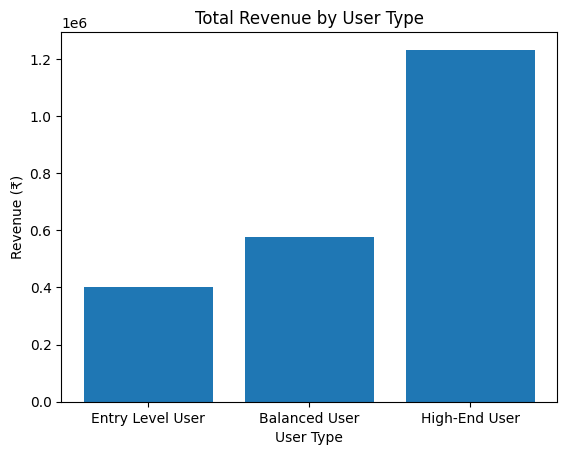

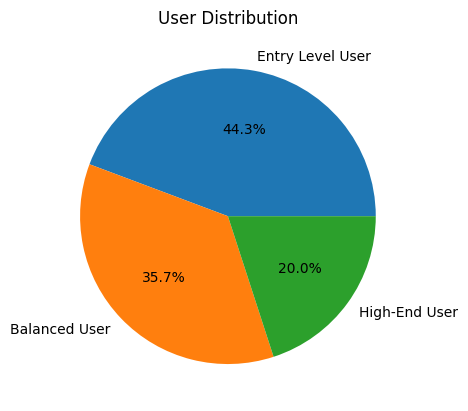


🔹 REVENUE INSIGHTS:

1. High-End users contribute the highest revenue due to expensive smartphone purchases.

2. Upsell generates more revenue compared to cross-sell, making it the primary profit driver.

3. Cross-sell still adds significant value by increasing the total bill per customer.

4. Balanced users provide steady and consistent revenue across both upsell and cross-sell.

5. Entry-level users contribute lower revenue per person but help in volume-based sales.

6. Combining both strategies results in maximum overall revenue for the business.



In [ ]:
# ==============================
# 🔹 STEP 1: LOAD DATASET
# ==============================
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

survey_df = pd.read_excel("clean_survey_dataset.xlsx")

print("Dataset Loaded Successfully ✅")
display(survey_df.head())


# ==============================
# 🔹 STEP 2: USER SEGMENTATION
# ==============================

def categorize_user(budget):
    if budget == "Below 10k":
        return "Entry Level User"
    elif budget == "10k-30k":
        return "Balanced User"
    else:
        return "High-End User"

survey_df['User_Category'] = survey_df['Budget'].apply(categorize_user)

entry_users = len(survey_df[survey_df['User_Category'] == 'Entry Level User'])
mid_users = len(survey_df[survey_df['User_Category'] == 'Balanced User'])
premium_users = len(survey_df[survey_df['User_Category'] == 'High-End User'])

print("\n🔹 User Distribution:")
print("Entry:", entry_users)
print("Balanced:", mid_users)
print("High-End:", premium_users)


# ==============================
# 🔹 STEP 3: RECOMMENDATION SYSTEM
# ==============================

recommendations = pd.DataFrame({

    "User_Type": ["Entry Level User", "Balanced User", "High-End User"],

    "Customer_Features": [
        "Price < ₹15K, 4GB RAM, 64GB Storage, Basic Camera, 4000mAh Battery",
        "₹15K–₹30K, 6GB RAM, 128GB Storage, Good Camera, 5000mAh Battery",
        "> ₹30K, 8–12GB RAM, 256GB Storage, High Camera, 5000mAh+ Battery"
    ],

    "Upsell_Recommendation": [
        "Samsung Galaxy F14 (₹12K) → Galaxy M34 (₹18K)",
        "Samsung Galaxy M34 (₹18K) → Galaxy S21 FE (₹32K)",
        "Samsung Galaxy S23 (₹75K) → Galaxy S24 Ultra (₹1.2L)"
    ],

    "CrossSell_Recommendation": [
        "Basic Earphones, Charging Cable, Phone Case",
        "Bluetooth Earbuds, Fast Charger, Power Bank",
        "Galaxy Buds, Wireless Charger, Premium Power Bank"
    ],

    "Downgrade_Recommendation": [
        "Samsung Galaxy M04 (₹8K) for lower budget",
        "Samsung Galaxy F14 (₹12K) for cost saving",
        "Samsung Galaxy A34 (₹25K) as budget flagship alternative"
    ]
})

print("\n🔹 Smart Recommendation System (Upsell, Cross-Sell & Downgrade):")
display(recommendations)


# ==============================
# 🔹 STEP 4: PRICE DEFINITIONS
# ==============================

price_map = {
    "Entry Level User": 12000,
    "Balanced User": 20000,
    "High-End User": 80000
}

accessory_price = {
    "Entry Level User": 1000,
    "Balanced User": 3000,
    "High-End User": 8000
}


# ==============================
# 🔹 STEP 5: REVENUE CALCULATION
# ==============================

entry_upsell = entry_users * price_map["Entry Level User"]
mid_upsell = mid_users * price_map["Balanced User"]
premium_upsell = premium_users * price_map["High-End User"]

entry_cross = entry_users * accessory_price["Entry Level User"]
mid_cross = mid_users * accessory_price["Balanced User"]
premium_cross = premium_users * accessory_price["High-End User"]

entry_total = entry_upsell + entry_cross
mid_total = mid_upsell + mid_cross
premium_total = premium_upsell + premium_cross

grand_total = entry_total + mid_total + premium_total


# ==============================
# 🔹 STEP 6: FINAL REVENUE TABLE
# ==============================

revenue_df = pd.DataFrame({
    "User_Type": ["Entry Level User", "Balanced User", "High-End User"],
    "Users": [entry_users, mid_users, premium_users],
    "Upsell Revenue (₹)": [entry_upsell, mid_upsell, premium_upsell],
    "Cross-Sell Revenue (₹)": [entry_cross, mid_cross, premium_cross],
    "Total Revenue (₹)": [entry_total, mid_total, premium_total]
})

print("\n🔹 FINAL REVENUE ANALYSIS:")
display(
    revenue_df.style.format({
        "Upsell Revenue (₹)": "₹{:,.0f}",
        "Cross-Sell Revenue (₹)": "₹{:,.0f}",
        "Total Revenue (₹)": "₹{:,.0f}"
    })
)

print(f"\n💰 GRAND TOTAL REVENUE GENERATED: ₹{grand_total:,}")


# ==============================
# 🔹 STEP 7: GRAPH 1 (REVENUE)
# ==============================

plt.figure()
plt.bar(revenue_df["User_Type"], revenue_df["Total Revenue (₹)"])
plt.title("Total Revenue by User Type")
plt.xlabel("User Type")
plt.ylabel("Revenue (₹)")
plt.show()


# ==============================
# 🔹 STEP 8: GRAPH 2 (USER DISTRIBUTION)
# ==============================

plt.figure()
plt.pie(revenue_df["Users"], labels=revenue_df["User_Type"], autopct='%1.1f%%')
plt.title("User Distribution")
plt.show()
print("\n🔹 REVENUE INSIGHTS:")

print("""
1. High-End users contribute the highest revenue due to expensive smartphone purchases.

2. Upsell generates more revenue compared to cross-sell, making it the primary profit driver.

3. Cross-sell still adds significant value by increasing the total bill per customer.

4. Balanced users provide steady and consistent revenue across both upsell and cross-sell.

5. Entry-level users contribute lower revenue per person but help in volume-based sales.

6. Combining both strategies results in maximum overall revenue for the business.
""")